In [1]:
import sys
sys.path.insert(0, '..')

from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                    compute_cell_metrics, neighbor_qa, flag_outlier_pairs,
                    compute_R_for_dumps)
from plotters import plot_spectra_grid, plot_survey_mollweide
from ugradiolab import plotting
from ugradiolab.plotting import SS_FINE

from pathlib import Path
from collections import defaultdict
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt
import json
import numpy as np
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405751768
C_KMS = 299792.458

F1_MHZ = 1420.0
F2_MHZ = 1421.0

T_CAL_00 = 58.0  # K, pol 0
T_CAL_11 = 79.0  # K, pol 1
T_CAL_I = T_CAL_00 + T_CAL_11  # Stokes I = corr00 + corr11

HPBW_DEG = 3.4

# --- RFI channel flagger (utils.flag_rfi_channels) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter (utils.flag_outlier_dumps) ---
SHAPE_DEV_THRESH = 0.10
SHAPE_FRAC_THRESH = 0.20
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Cross-session pair filter (utils.flag_outlier_pairs) ---
# Filter on T_B (K) so a session with anomalous T_sys becomes a population
# outlier in absolute units, not just spectral shape.
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3
PAIR_SPECTRUM_KEY = 'T_B_lsr'

# --- Per-cell metrics (utils.compute_cell_metrics) ---
METRIC_MIN_VALID_CH = 8
METRIC_NOISE_V_MAX_KMS = -100.0
METRIC_SIGNAL_V_LO_KMS = -80.0
METRIC_SIGNAL_V_HI_KMS = 60.0
METRIC_SMOOTH_KERNEL = 5
METRIC_PEAK_MIN_SEP_KMS = 4.0
METRIC_PEAK_PROM_NSIGMA = 2.5
METRIC_MIN_NOISE_CH = 5

# --- Neighbor QA (utils.neighbor_qa) ---
# Operates on T_B (K), so W is in K*km/s. W_SCALE_FLOOR is the denominator
# floor for W_frac_resid. Streaming survey uses an integer 2-deg grid (no
# half-row offset), so the 4 axis-aligned neighbors sit at exactly 2.0 deg
# and the 4 diagonals at ~2.83 deg; 3.0 deg captures the full ring-1.
NEIGHBOR_MAX_SEP_DEG = 3.0
MIN_NEIGHBORS = 5
W_Z_THRESH = 3.0
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 1000.0
PEAK_V_Z_THRESH = 3.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0
BIMODAL_MIN_RATIO = 0.68

# --- T_sys QA (per-session) ---
T_SYS_NSIGMA = 4.0
T_SYS_ABS_LO = 80.0
T_SYS_ABS_HI = 400.0  # streaming Stokes-I-sum chain runs hotter

# --- Paths / display ---
DATA_DIR = Path('../../../data/lab04/streaming')
REOBSERVE_PATH = Path('../scripts/reobserve.json')
MOLL_CENTER_L = 120.0

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps

In [2]:
records = []
for session_dir in sorted(DATA_DIR.glob('session_*')):
    for cell_dir in (sorted(session_dir.glob('obs_*'))
                     + sorted(session_dir.glob('cal_*'))):
        is_cal_cell = cell_dir.name.startswith('cal_')
        for p in sorted(cell_dir.glob('*.npz')):
            with np.load(p, allow_pickle=True) as f:
                records.append({
                    'path': p,
                    'session': session_dir.name,
                    'is_cal_cell': is_cal_cell,
                    'target': str(f['target_name']),
                    'corr00': f['corr00'].astype(float),
                    'corr11': f['corr11'].astype(float),
                    'lo_mhz': float(f['lo_freq_mhz']),
                    'noise_on': bool(f['noise_on']),
                    'time': float(f['time']),
                    'alt': float(f['alt_deg']),
                    'az': float(f['az_deg']),
                    'ra': float(f['ra_deg']),
                    'dec': float(f['dec_deg']),
                })

N = len(records)

# Galactic coordinates from RA/Dec (integer-rounded for streaming survey grid)
for r in records:
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg)
    r['gb'] = round(c.galactic.b.deg)

sessions = sorted(set(r['session'] for r in records))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal_on = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'] and not r['is_cal_cell'])
n_cal_off = sum(1 for r in records if not r['noise_on'] and r['is_cal_cell'])

# Integration time per dump (seconds): NBLOCKS * NSAMPLES / fs
INT_TIME_S = 1025 * 32768 / SAMPLE_RATE_HZ


def _utc(ts):
    return dt.datetime.fromtimestamp(ts, dt.UTC).strftime('%Y-%m-%d %H:%M')


session_data = []
for s in sessions:
    s_records = [r for r in records if r['session'] == s]
    n_dumps = len(s_records)
    if n_dumps == 0:
        continue
    n_cells = len({(r['gl'], r['gb']) for r in s_records
                   if not r['noise_on'] and not r['is_cal_cell']})
    times = [r['time'] for r in s_records]
    t0, t1 = min(times), max(times)
    wall_s = t1 - t0
    duty_pct = (INT_TIME_S * n_dumps / wall_s) * 100 if wall_s > 0 else float('nan')
    session_data.append({
        'Session': s,
        'UTC Start': _utc(t0),
        'UTC End':   _utc(t1),
        'Wall (min)': round(wall_s / 60, 1),
        'Obs. Cells': n_cells,
        'Dumps': n_dumps,
        'Duty %': round(duty_pct, 1),
    })
display(pd.DataFrame(session_data))

print(f'Total: {N} dumps ({n_sci} science, {n_cal_off} cal-off, '
      f'{n_cal_on} cal-on), {len(sessions)} sessions, LO: {lo_unique}')

,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,session_001,2026-04-16 09:57,2026-04-16 19:59,601.6,153,1225,44.5
1,session_002,2026-04-17 05:20,2026-04-17 08:57,217.8,14,432,43.4
2,session_003,2026-04-17 10:19,2026-04-17 16:32,372.5,95,758,44.5
3,session_004,2026-04-17 19:31,2026-04-17 22:01,150.0,67,537,78.3
4,session_005,2026-04-18 00:45,2026-04-18 01:27,41.8,19,149,78.0
5,session_006,2026-04-18 01:33,2026-04-18 05:05,211.8,97,775,80.0
6,session_007,2026-04-18 09:05,2026-04-18 12:03,178.5,80,641,78.5
7,session_008,2026-04-18 17:49,2026-04-18 20:29,160.4,75,601,81.9
8,session_009,2026-04-18 21:32,2026-04-19 03:09,336.7,153,1225,79.6
9,session_010,2026-04-19 03:12,2026-04-19 04:39,87.4,40,321,80.3


Total: 13938 dumps (13792 science, 0 cal-off, 146 cal-on), 36 sessions, LO: [1420.0, 1421.0]


## 2. fftshift + RFI flagging + outlier dump filter

In [3]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])
    r['stokes_I'] = r['corr00'] + r['corr11']

n_flagged = sum(
    flag_rfi_channels(
        r['stokes_I'],
        window=RFI_WINDOW,
        sigma_thresh=RFI_SIGMA,
        degree=RFI_CHEB_DEGREE,
        sample_frac=RFI_SAMPLE_FRAC,
        extrema_order=RFI_EXTREMA_ORDER,
    )
    for r in records
)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz, '
      f'dnu = {df_khz:.2f} kHz')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')
print('NOTE: Stokes I = corr00 + corr11')

Baseband: [-1.280, 1.278] MHz, dnu = 2.50 kHz
RFI flagged: 93633 samples across 13938 dumps
NOTE: Stokes I = corr00 + corr11


In [4]:
outlier_records = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
N = len(records)

print(f'Outlier dump filter (spectral shape): removed {len(outlier_records)} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {N} dumps')

Outlier dump filter (spectral shape): removed 31 dumps
  (flag if >20% of channels deviate >10% from group median)
Remaining: 13907 dumps


## 4. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.

In [5]:
lo1, lo2 = F1_MHZ, F2_MHZ
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)
dv_kms = np.abs(np.median(np.diff(v_overlap)))

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')

# Frequency-switched R per (session, cell), science cells only.
all_pointings = sorted({(r['gl'], r['gb']) for r in records
                        if r['gl'] is not None and not r['is_cal_cell']})

cell_results = {}
for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb
                 and not r['noise_on'] and not r['is_cal_cell']]
    for dr in sessions:
        dr_dumps = [r for r in sci_dumps if r['session'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz
Velocity (topo): [-130, 90] km/s
dv = 0.528 km/s per channel


/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:107: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)


## 5. Per-session gain calibration

Each streaming session opens with a calibration block at a fixed pointing
(stored under `cal_*/`, noise-on only). The noise-off reference for that
block is the noise-off dumps recorded across the session (the `obs_*/`
science dumps -- LO-switching alternates noise on/off frequently enough
that any noise-off dump in the session is a valid baseline). Per session,
`gain = (P_on - P_off) / T_cal` on Stokes I and `T_sys = mean(P_off / gain)`.
All science cells in a session inherit the same scalar `T_sys`.

In [6]:
dc_mask = np.ones(NFFT, dtype=bool)
dc_mask[DC_BIN] = False

session_calib = {}
for s in sessions:
    s_recs = [r for r in records if r['session'] == s]
    cal_on = [r['stokes_I'] for r in s_recs if r['noise_on']]
    cal_off = [r['stokes_I'] for r in s_recs if not r['noise_on']]
    if not cal_on or not cal_off:
        continue
    P_on = np.nanmean(cal_on, axis=0)
    P_off = np.nanmean(cal_off, axis=0)
    gain = (P_on - P_off) / T_CAL_I
    gain_safe = np.where(np.abs(gain) > 0, gain, np.nan)
    T_sys_spec = P_off / gain_safe
    T_sys = float(np.nanmean(T_sys_spec[dc_mask]))
    session_calib[s] = {
        'gain': gain, 'T_sys': T_sys,
        'n_cal_on': len(cal_on), 'n_cal_off': len(cal_off),
    }

calib_rows = [
    {'session': s, 'n_cal_on': v['n_cal_on'], 'n_cal_off': v['n_cal_off'],
     'gain_med': float(np.nanmedian(v['gain'])), 'T_sys': v['T_sys']}
    for s, v in sorted(session_calib.items())
]
calib_df = pd.DataFrame(calib_rows)
display(calib_df)

if len(calib_df):
    print(f'Calibrated {len(session_calib)}/{len(sessions)} sessions')
    print(f'  gain (median): {calib_df["gain_med"].median():.3g}')
    print(f'  T_sys: median {calib_df["T_sys"].median():.0f} K, '
          f'range [{calib_df["T_sys"].min():.0f}, '
          f'{calib_df["T_sys"].max():.0f}] K')

uncal_sessions = [s for s in sessions if s not in session_calib]
if uncal_sessions:
    print(f'  WARNING: no calibration for {len(uncal_sessions)} sessions: '
          f'{uncal_sessions}')

/tmp/ipykernel_9046/734740317.py:11: RuntimeWarning: Mean of empty slice
  P_on = np.nanmean(cal_on, axis=0)
/tmp/ipykernel_9046/734740317.py:12: RuntimeWarning: Mean of empty slice
  P_off = np.nanmean(cal_off, axis=0)


,session,n_cal_on,n_cal_off,gain_med,T_sys
0,session_001,4,1221,112.042991,55.308350
1,session_002,4,428,43.204822,134.070656
2,session_003,4,754,57.527207,111.788156
3,session_004,4,532,35.928250,149.450806
4,session_005,4,144,34.078703,173.224089
5,session_006,4,770,29.733047,216.807664
6,session_007,4,636,65.796773,99.727765
7,session_008,4,596,65.705367,88.725836
8,session_009,4,1220,31.333833,167.619467
9,session_010,4,317,27.072954,212.672676


Calibrated 36/36 sessions
  gain (median): 37.1
  T_sys: median 158 K, range [50, 305] K


## 6. LSR correction, cross-session pair filter, and combine

Build per-pair R for each cell across all sessions, LSR-shift each pair onto a
common grid, reject outlier pairs via population MAD (cross-session), then
average the surviving pairs. Cells with fewer than `MIN_VIABLE_PAIRS` after
filtering are queued for reobservation.

In [7]:
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on'] or r['is_cal_cell']:
        continue
    cell_dr_groups[(r['session'], r['gl'], r['gb'])].append(r)

session_cell_vcorr = {}
for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    session_cell_vcorr[key] = vlsr_correction(r0['ra'], r0['dec'], mean_t)

sci_vcorr = list(session_cell_vcorr.values())
mean_vcorr = float(np.mean(sci_vcorr)) if sci_vcorr else 0.0
v_lsr_overlap = v_overlap + mean_vcorr
v_lsr_inc = v_lsr_overlap[::-1]

if sci_vcorr:
    print(f'v_corr range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
          f'(mean {mean_vcorr:.2f})')
    print(f'Velocity (LSR): [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')
else:
    print('No science dumps -- skipping LSR correction')

# Group obs dumps by (session, cell) for pair construction.
obs_dumps_by_cell = defaultdict(list)
for r in records:
    if r['noise_on'] or r['is_cal_cell'] or r.get('gl') is None:
        continue
    obs_dumps_by_cell[(r['session'], r['gl'], r['gb'])].append(r)

# Build per-pair (R_lsr, T_B_lsr) for each (gl, gb), LSR-shifted onto the
# common grid. T_B_lsr = R_lsr * T_sys[session] -- pre-multiplying by the
# session's T_sys lets the cross-session pair filter catch sessions with
# anomalous gain/T_sys, not just shape outliers. R_lsr is preserved for the
# uncalibrated W_R sanity-check map.
cell_pairs = defaultdict(list)
n_pairs_no_tsys = 0

for (dr, gl, gb), dumps in obs_dumps_by_cell.items():
    d1 = [r for r in dumps if r['lo_mhz'] == lo1]
    d2 = [r for r in dumps if r['lo_mhz'] == lo2]
    n_p = min(len(d1), len(d2))
    if n_p == 0:
        continue

    T_sys_s = session_calib.get(dr, {}).get('T_sys', np.nan)
    if not np.isfinite(T_sys_s):
        n_pairs_no_tsys += n_p
        continue

    I1 = np.array([r['stokes_I'] for r in d1[:n_p]])
    I2 = np.array([r['stokes_I'] for r in d2[:n_p]])
    R_pairs = (I1 - I2) / I2  # (n_p, NFFT)
    R_pairs_ov = R_pairs[:, overlap_mask]

    v_corr = session_cell_vcorr.get((dr, gl, gb), 0.0)
    v_shifted = v_overlap + v_corr

    for i in range(n_p):
        R_lsr = np.interp(v_lsr_inc, v_shifted[::-1],
                          R_pairs_ov[i][::-1],
                          left=np.nan, right=np.nan)[::-1]
        cell_pairs[(gl, gb)].append({
            'session': dr,
            'pair_idx': i,
            'R_lsr': R_lsr,
            'T_B_lsr': R_lsr * T_sys_s,
        })

if n_pairs_no_tsys:
    print(f'Skipped {n_pairs_no_tsys} pairs with missing T_sys')

# Cross-session per-pair outlier filter on T_B (K).
n_pairs_total = sum(len(v) for v in cell_pairs.values())
viable_pairs_per_cell, flagged_pair_records = flag_outlier_pairs(
    cell_pairs,
    n_sigma=PAIR_NSIGMA,
    frac_thresh=PAIR_FRAC_THRESH,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Pair filter (on {PAIR_SPECTRUM_KEY}): flagged '
      f'{len(flagged_pair_records)}/{n_pairs_total} pairs '
      f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')

# Aggregate viable pairs into cell_combined. T_B is already per-pair so
# the average uses each pair's source-session T_sys implicitly.
cell_combined = {}
cells_insufficient_pairs = []

for (gl, gb), pairs in viable_pairs_per_cell.items():
    TB_list = [p['T_B_lsr'] for p in pairs]
    R_list = [p['R_lsr'] for p in pairs]
    tsys_list = [session_calib[p['session']]['T_sys']
                 for p in pairs if p['session'] in session_calib]

    n_viable = len(TB_list)
    if n_viable == 0:
        cells_insufficient_pairs.append({'l': gl, 'b': int(gb), 'n_viable': 0})
        continue

    cell_combined[(gl, gb)] = {
        'T_B': np.nanmean(TB_list, axis=0),
        'R': np.nanmean(R_list, axis=0),
        'T_sys': float(np.mean(tsys_list)) if tsys_list else np.nan,
        'n_pairs': n_viable,
    }

    if n_viable < MIN_VIABLE_PAIRS:
        cells_insufficient_pairs.append({'l': gl, 'b': int(gb), 'n_viable': n_viable})

n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['T_B'])) >= 8)
print(f'Combined (LSR): {len(cell_combined)} cells ({n_valid} with >=8 valid channels)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')

Computing LSR corrections...
v_corr range: -43.89 to 43.33 km/s (mean -13.66)
Velocity (LSR): [-143, 77] km/s


/home/ikaros/projects/ay-121/labs/04/notebooks/utils/qa.py:547: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/utils/qa.py:548: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826


Pair filter (on T_B_lsr): flagged 228/6829 pairs (NSIGMA=5.0, frac>15%)
Combined (LSR): 1636 cells (1636 with >=8 valid channels)
Cells with <3 viable pairs: 19


/tmp/ipykernel_9046/305957654.py:105: RuntimeWarning: Mean of empty slice
  'T_B': np.nanmean(TB_list, axis=0),
/tmp/ipykernel_9046/305957654.py:106: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(R_list, axis=0),


# N. Neighbour-based QA

In [8]:
# QA runs on T_B (K), so W is in K*km/s and noise_rms is in K. This makes the
# neighbor comparison and W_sigma_floor physically meaningful and not biased
# by cell-to-cell T_sys variation.
cell_combined_qa = {
    k: {'R_overlap': v['T_B'], 'n_pairs': v['n_pairs']}
    for k, v in cell_combined.items()
}

cell_metrics = compute_cell_metrics(
    cell_combined_qa, v_lsr_overlap, dv_kms,
    min_valid_ch=METRIC_MIN_VALID_CH,
    noise_v_max_kms=METRIC_NOISE_V_MAX_KMS,
    signal_v_lo_kms=METRIC_SIGNAL_V_LO_KMS,
    signal_v_hi_kms=METRIC_SIGNAL_V_HI_KMS,
    smooth_kernel=METRIC_SMOOTH_KERNEL,
    peak_min_sep_kms=METRIC_PEAK_MIN_SEP_KMS,
    peak_prom_nsigma=METRIC_PEAK_PROM_NSIGMA,
    min_noise_ch=METRIC_MIN_NOISE_CH,
)
neighbor_cells = neighbor_qa(
    cell_metrics,
    dv_kms=dv_kms,
    hpbw_deg=HPBW_DEG,
    neighbor_max_sep_deg=NEIGHBOR_MAX_SEP_DEG,
    min_neighbors=MIN_NEIGHBORS,
    w_z_thresh=W_Z_THRESH,
    w_frac_thresh=W_FRAC_THRESH,
    w_scale_floor=W_SCALE_FLOOR,
    peak_v_z_thresh=PEAK_V_Z_THRESH,
    peak_v_abs_thresh=PEAK_V_ABS_THRESH,
    peak_v_min_sigma=PEAK_V_MIN_SIGMA,
    peak_v_scale_floor=PEAK_V_SCALE_FLOOR,
    bimodal_min_ratio=BIMODAL_MIN_RATIO,
)

neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
neighbor_w_flag_count = sum(1 for c in neighbor_cells if c['W_flag'])
neighbor_peak_flag_count = sum(1 for c in neighbor_cells if c['peak_v_flag'])

print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed (on T_B)')
print(f'  Flags: W={neighbor_w_flag_count}, peak_v={neighbor_peak_flag_count}, '
      f'any={len(neighbor_flagged)}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def severity(cell):
        w_score = abs(cell['W_frac_resid']) if np.isfinite(cell['W_frac_resid']) else 0.0
        v_score = abs(cell['peak_v_z']) if np.isfinite(cell['peak_v_z']) else 0.0
        return max(w_score, v_score)

    for cell in sorted(neighbor_flagged, key=severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:4d} b={cell['gb']:+3d} "
            f"W={cell['W']:+.1f} K*km/s (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )

Neighbor QA: 1636 cells analyzed (on T_B)
  Flags: W=47, peak_v=4, any=51
  Most deviant cells:
    l=  46 b= -2 W=+1954.0 K*km/s (frac=-0.02, z=-0.26) v_peak=+7.1 km/s (dv=-16.9, z=-5.65) n=8
    l=  46 b= +2 W=+2230.3 K*km/s (frac=+0.12, z=+1.34) v_peak=+6.5 km/s (dv=-16.8, z=-5.59) n=8
    l=  44 b= +2 W=+2047.7 K*km/s (frac=+0.02, z=+0.49) v_peak=+6.0 km/s (dv=-19.4, z=-5.05) n=8
    l=  44 b= +0 W=+2560.0 K*km/s (frac=+0.18, z=+4.01) v_peak=+57.7 km/s (dv=+36.8, z=+3.47) n=8
    l= 142 b= -4 W=+2293.4 K*km/s (frac=-0.41, z=-5.72) v_peak=-0.8 km/s (dv=-6.9, z=-1.72) n=7
    l= 266 b=+24 W=+2591.6 K*km/s (frac=+1.70, z=+12.81) v_peak=-3.5 km/s (dv=+0.4, z=+0.15) n=8
    l=  42 b= +4 W=+1973.3 K*km/s (frac=+1.21, z=+10.93) v_peak=+6.0 km/s (dv=+0.3, z=+0.05) n=5
    l= 142 b= -2 W=+2838.0 K*km/s (frac=-0.39, z=-3.07) v_peak=-36.2 km/s (dv=-14.0, z=-1.19) n=12
    l=  30 b= +2 W=+1174.2 K*km/s (frac=-0.43, z=-3.30) v_peak=+12.9 km/s (dv=+3.5, z=+1.18) n=8
    l= 113 b= +1 W=+6443.2 K*

# N+. T_sys QA

Per-cell `T_sys` is the mean across viable pairs in `cell_combined`. Flag
cells whose `T_sys` lies more than `T_SYS_NSIGMA` robust standard
deviations (1.4826 * MAD) from the population median. Severe T_sys
excursions usually point to a bad cal-on/off block (noise diode partially
fired, scan boundary inside the cal pair, or unusually high ambient
temperature), and propagate silently into `T_B` since `T_B = R * T_sys`.

In [9]:
# T_SYS_NSIGMA, T_SYS_ABS_LO, T_SYS_ABS_HI defined in the config cell.

# Per-session calibration -> all cells in a session share T_sys, so a deviant
# session shows up here as a cluster of identical-T_sys cells beyond the cut.
tsys_cells = []
for (gl, gb), v in cell_combined.items():
    tsys = float(v.get('T_sys', np.nan))
    if not np.isfinite(tsys):
        continue
    tsys_cells.append({'gl': gl, 'gb': gb, 'T_sys': tsys,
                       'n_pairs': v.get('n_pairs', 0)})

tsys_arr = np.array([c['T_sys'] for c in tsys_cells])
tsys_med = float(np.median(tsys_arr)) if tsys_arr.size else np.nan
tsys_mad = (float(np.median(np.abs(tsys_arr - tsys_med)))
            if tsys_arr.size else np.nan)
tsys_sigma = 1.4826 * tsys_mad if tsys_mad and tsys_mad > 0 else np.nan

for c in tsys_cells:
    z = ((c['T_sys'] - tsys_med) / tsys_sigma
         if np.isfinite(tsys_sigma) else 0.0)
    c['T_sys_z'] = z
    c['T_sys_flag'] = (abs(z) > T_SYS_NSIGMA
                      or c['T_sys'] < T_SYS_ABS_LO
                      or c['T_sys'] > T_SYS_ABS_HI)

tsys_flagged = [c for c in tsys_cells if c['T_sys_flag']]

print(f'T_sys QA: {len(tsys_cells)} cells analyzed')
print(f'  median = {tsys_med:.1f} K, robust sigma = {tsys_sigma:.1f} K')
print(f'  threshold: |z| > {T_SYS_NSIGMA} OR T_sys outside '
      f'[{T_SYS_ABS_LO:.0f}, {T_SYS_ABS_HI:.0f}] K')
print(f'  Flagged: {len(tsys_flagged)} cells')

if tsys_flagged:
    print('  Most deviant cells:')
    for c in sorted(tsys_flagged, key=lambda x: abs(x['T_sys_z']),
                    reverse=True)[:12]:
        print(f"    l={c['gl']:4d} b={c['gb']:+3d} "
              f"T_sys={c['T_sys']:6.1f} K  z={c['T_sys_z']:+.2f}  "
              f"n_pairs={c['n_pairs']}")

T_sys QA: 1636 cells analyzed
  median = 154.3 K, robust sigma = 30.0 K
  threshold: |z| > 4.0 OR T_sys outside [80, 400] K
  Flagged: 296 cells
  Most deviant cells:
    l=  50 b= -2 T_sys= 304.8 K  z=+5.01  n_pairs=4
    l=  52 b= -4 T_sys= 304.8 K  z=+5.01  n_pairs=3
    l=  54 b= -4 T_sys= 304.8 K  z=+5.01  n_pairs=3
    l=  56 b= -2 T_sys= 304.8 K  z=+5.01  n_pairs=3
    l=  56 b= -4 T_sys= 304.8 K  z=+5.01  n_pairs=4
    l=  56 b= +0 T_sys= 304.8 K  z=+5.01  n_pairs=3
    l=  56 b= +2 T_sys= 304.8 K  z=+5.01  n_pairs=4
    l=  58 b= -2 T_sys= 304.8 K  z=+5.01  n_pairs=3
    l=  58 b= +0 T_sys= 304.8 K  z=+5.01  n_pairs=4
    l=  58 b= +2 T_sys= 304.8 K  z=+5.01  n_pairs=3
    l=  58 b= +4 T_sys= 304.8 K  z=+5.01  n_pairs=4
    l= 254 b=+16 T_sys=  49.6 K  z=-3.49  n_pairs=4


In [10]:
# Cells to reobserve: union of neighbor-QA flags, insufficient pairs, T_sys outliers.
reobs_map = {}  # (l, b) -> {'l', 'b', 'reason'}

for c in neighbor_cells:
    if not (c['W_flag'] or c['peak_v_flag']):
        continue
    flags = []
    if c['W_flag']:
        flags.append('W')
    if c['peak_v_flag']:
        flags.append('peak_v')
    key = (c['gl'], int(c['gb']))
    reobs_map[key] = {'l': c['gl'], 'b': int(c['gb']),
                      'reason': '+'.join(flags)}

for c in cells_insufficient_pairs:
    key = (c['l'], int(c['b']))
    tag = f"insufficient_pairs(n={c['n_viable']})"
    if key in reobs_map:
        reobs_map[key]['reason'] += '+' + tag
    else:
        reobs_map[key] = {'l': c['l'], 'b': int(c['b']), 'reason': tag}

for c in tsys_flagged:
    key = (c['gl'], int(c['gb']))
    tag = f"T_sys({c['T_sys']:.0f}K,z={c['T_sys_z']:+.1f})"
    if key in reobs_map:
        reobs_map[key]['reason'] += '+' + tag
    else:
        reobs_map[key] = {'l': c['gl'], 'b': int(c['gb']), 'reason': tag}

reobs = sorted(reobs_map.values(), key=lambda r: (r['b'], r['l']))

REOBSERVE_PATH.parent.mkdir(parents=True, exist_ok=True)
REOBSERVE_PATH.write_text(json.dumps(reobs, indent=2) + '\n')
print(f'Wrote {REOBSERVE_PATH} -- {len(reobs)} cells')
for r in reobs:
    print(f"  l={r['l']:4d} b={r['b']:+3d}  ({r['reason']})")

Wrote ../scripts/reobserve.json -- 349 cells
  l= 198 b=-12  (W)
  l= 202 b=-12  (W)
  l=  12 b= -4  (T_sys(51K,z=-3.4))
  l=  14 b= -4  (T_sys(51K,z=-3.4))
  l=  16 b= -4  (T_sys(51K,z=-3.4))
  l=  18 b= -4  (T_sys(51K,z=-3.4))
  l=  20 b= -4  (T_sys(51K,z=-3.4))
  l=  22 b= -4  (T_sys(51K,z=-3.4))
  l=  24 b= -4  (T_sys(51K,z=-3.4))
  l=  26 b= -4  (T_sys(51K,z=-3.4))
  l=  28 b= -4  (T_sys(51K,z=-3.4))
  l=  30 b= -4  (T_sys(51K,z=-3.4))
  l=  32 b= -4  (T_sys(51K,z=-3.4))
  l=  34 b= -4  (T_sys(51K,z=-3.4))
  l=  36 b= -4  (T_sys(51K,z=-3.4))
  l=  38 b= -4  (T_sys(51K,z=-3.4))
  l=  40 b= -4  (T_sys(51K,z=-3.4))
  l=  42 b= -4  (T_sys(51K,z=-3.4))
  l=  44 b= -4  (T_sys(51K,z=-3.4))
  l=  46 b= -4  (T_sys(51K,z=-3.4))
  l=  52 b= -4  (W+T_sys(305K,z=+5.0))
  l=  54 b= -4  (T_sys(305K,z=+5.0))
  l=  56 b= -4  (T_sys(305K,z=+5.0))
  l=  78 b= -4  (T_sys(55K,z=-3.3))
  l=  79 b= -4  (T_sys(55K,z=-3.3))
  l=  80 b= -4  (T_sys(55K,z=-3.3))
  l=  81 b= -4  (T_sys(55K,z=-3.3))
  l=  82 b

In [11]:
# Cells the rest of the pipeline does not trust.
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
qa_flagged_set |= {(c['gl'], c['gb']) for c in tsys_flagged}
insufficient_set = {(c['l'], c['b']) for c in cells_insufficient_pairs}
excluded_cells = qa_flagged_set | insufficient_set

# Build per-(session, cell) R from the cross-session-filtered viable pairs.
# (Spectra are on the common LSR grid, not topocentric.)
viable_per_session_cell = defaultdict(list)
for (gl, gb), pairs in viable_pairs_per_cell.items():
    if (gl, gb) in excluded_cells:
        continue
    for p in pairs:
        viable_per_session_cell[(p['session'], gl, gb)].append(p['R_lsr'])


def _safe_nanmean_stack(rs):
    """nanmean over axis 0 without a warning when some columns are all-NaN."""
    stack = np.array(rs)
    col_has_data = np.any(np.isfinite(stack), axis=0)
    mean = np.full(stack.shape[1], np.nan)
    if col_has_data.any():
        mean[col_has_data] = np.nanmean(stack[:, col_has_data], axis=0)
    return mean


with PdfPages('spectra_per_session.pdf') as pdf:
    for dr in sessions:
        dr_spectra = {
            (l, b): _safe_nanmean_stack(rs)
            for (d, l, b), rs in viable_per_session_cell.items()
            if d == dr
        }
        if not dr_spectra:
            continue
        result = plot_spectra_grid(
            v_lsr_overlap, dr_spectra,
            ncols=5,
            color='C0',
            title=f'{dr} -- {len(dr_spectra)} pointings '
                  f'(post pair filter + QA, LSR frame)',
        )
        figs = result if isinstance(result, list) else [result]
        for f in figs:
            pdf.savefig(f)
            plt.close(f)

n_excluded = len(excluded_cells)
n_tsys = sum(1 for c in tsys_flagged)
print(f'Saved spectra_per_session.pdf '
      f'(excluded {n_excluded} cells: {len(qa_flagged_set)} QA '
      f'[incl. {n_tsys} T_sys] + {len(insufficient_set)} insufficient-pairs)')


Saved spectra_per_session.pdf (excluded 349 cells: 335 QA [incl. 296 T_sys] + 19 insufficient-pairs)


## 7a. Integrated frequency-switched ratio map W_R(l, b)

Same integration, but on the dimensionless frequency-switched ratio R(v)
rather than the calibrated brightness temperature T_B. Useful as a
sanity check decoupled from the per-cell T_sys calibration: structure
appearing here but not in W(l, b) (or vice versa) points to gain or
T_sys issues rather than astrophysics.

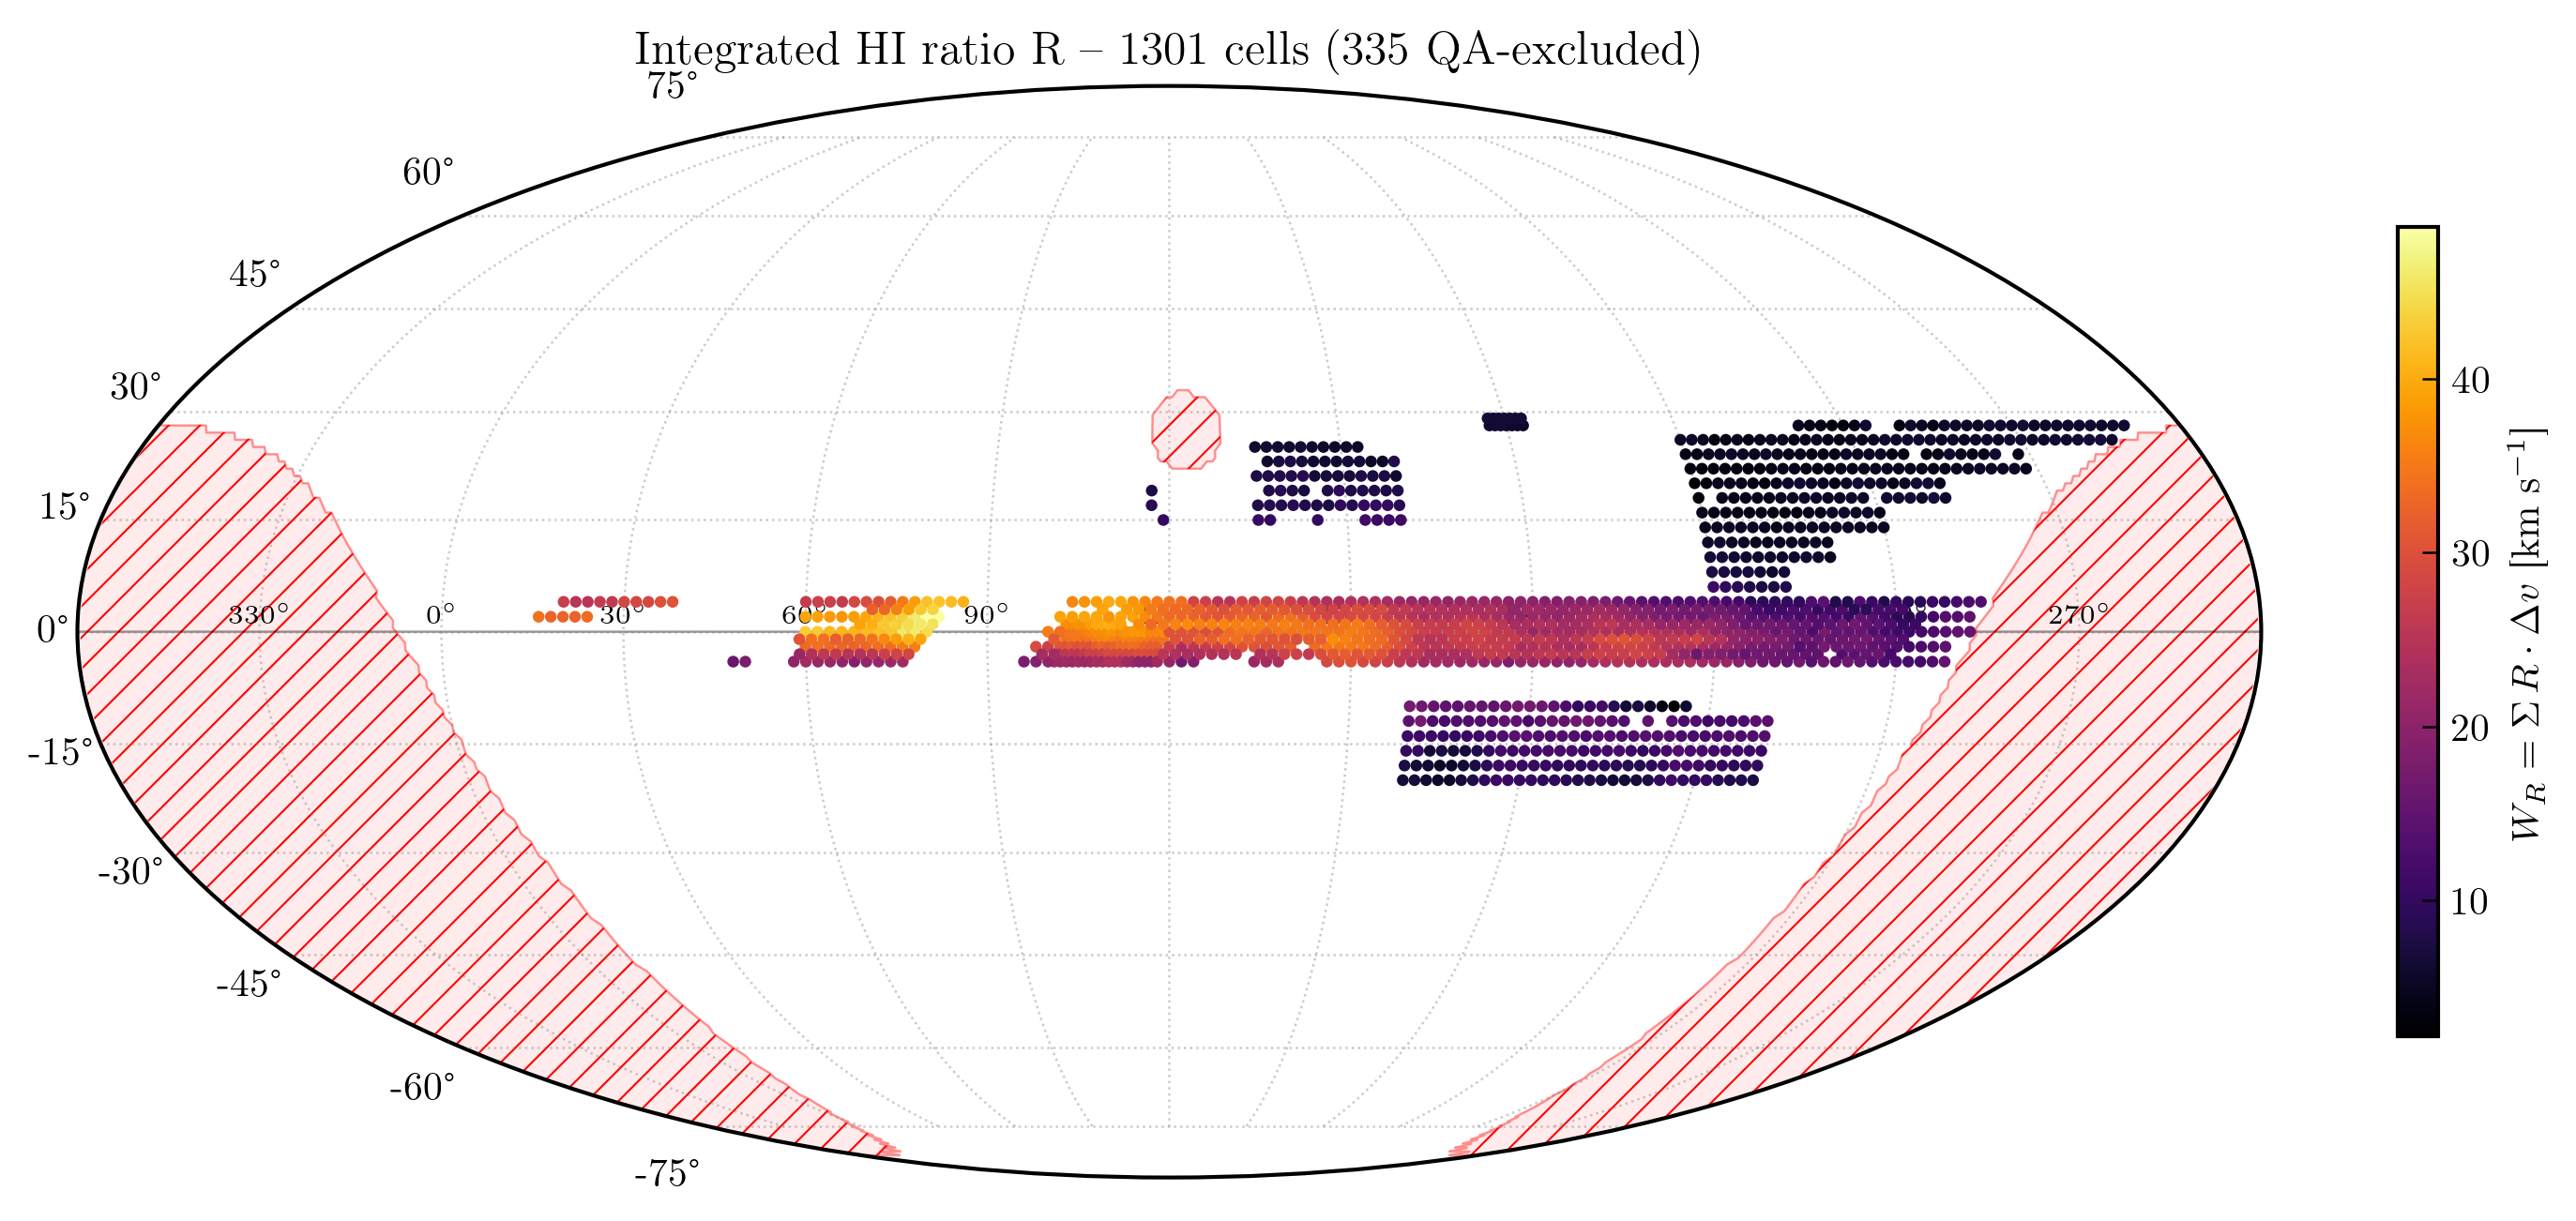

In [12]:
# QA-flagged cells to exclude (neighbor + T_sys outliers)
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
qa_flagged_set |= {(c['gl'], c['gb']) for c in tsys_flagged}

cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]

if not cell_keys_clean:
    print('No clean cells -- skipping W_R map')
else:
    gl_arr = np.array([k[0] for k in cell_keys_clean])
    gb_arr = np.array([k[1] for k in cell_keys_clean])
    R_stack = np.stack([cell_combined[k]['R'] for k in cell_keys_clean])

    W_R = np.nansum(R_stack, axis=1) * dv_kms
    valid_R = np.isfinite(W_R)

    fig, ax = plot_survey_mollweide(
        gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
        center_l=MOLL_CENTER_L,
        cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
        cmap='inferno',
        marker_size=SS_FINE,
        title=f'Integrated HI ratio R -- {valid_R.sum()} cells ({len(qa_flagged_set)} QA-excluded)',
    )
    plt.show()

## 7. Integrated intensity map W(l, b)

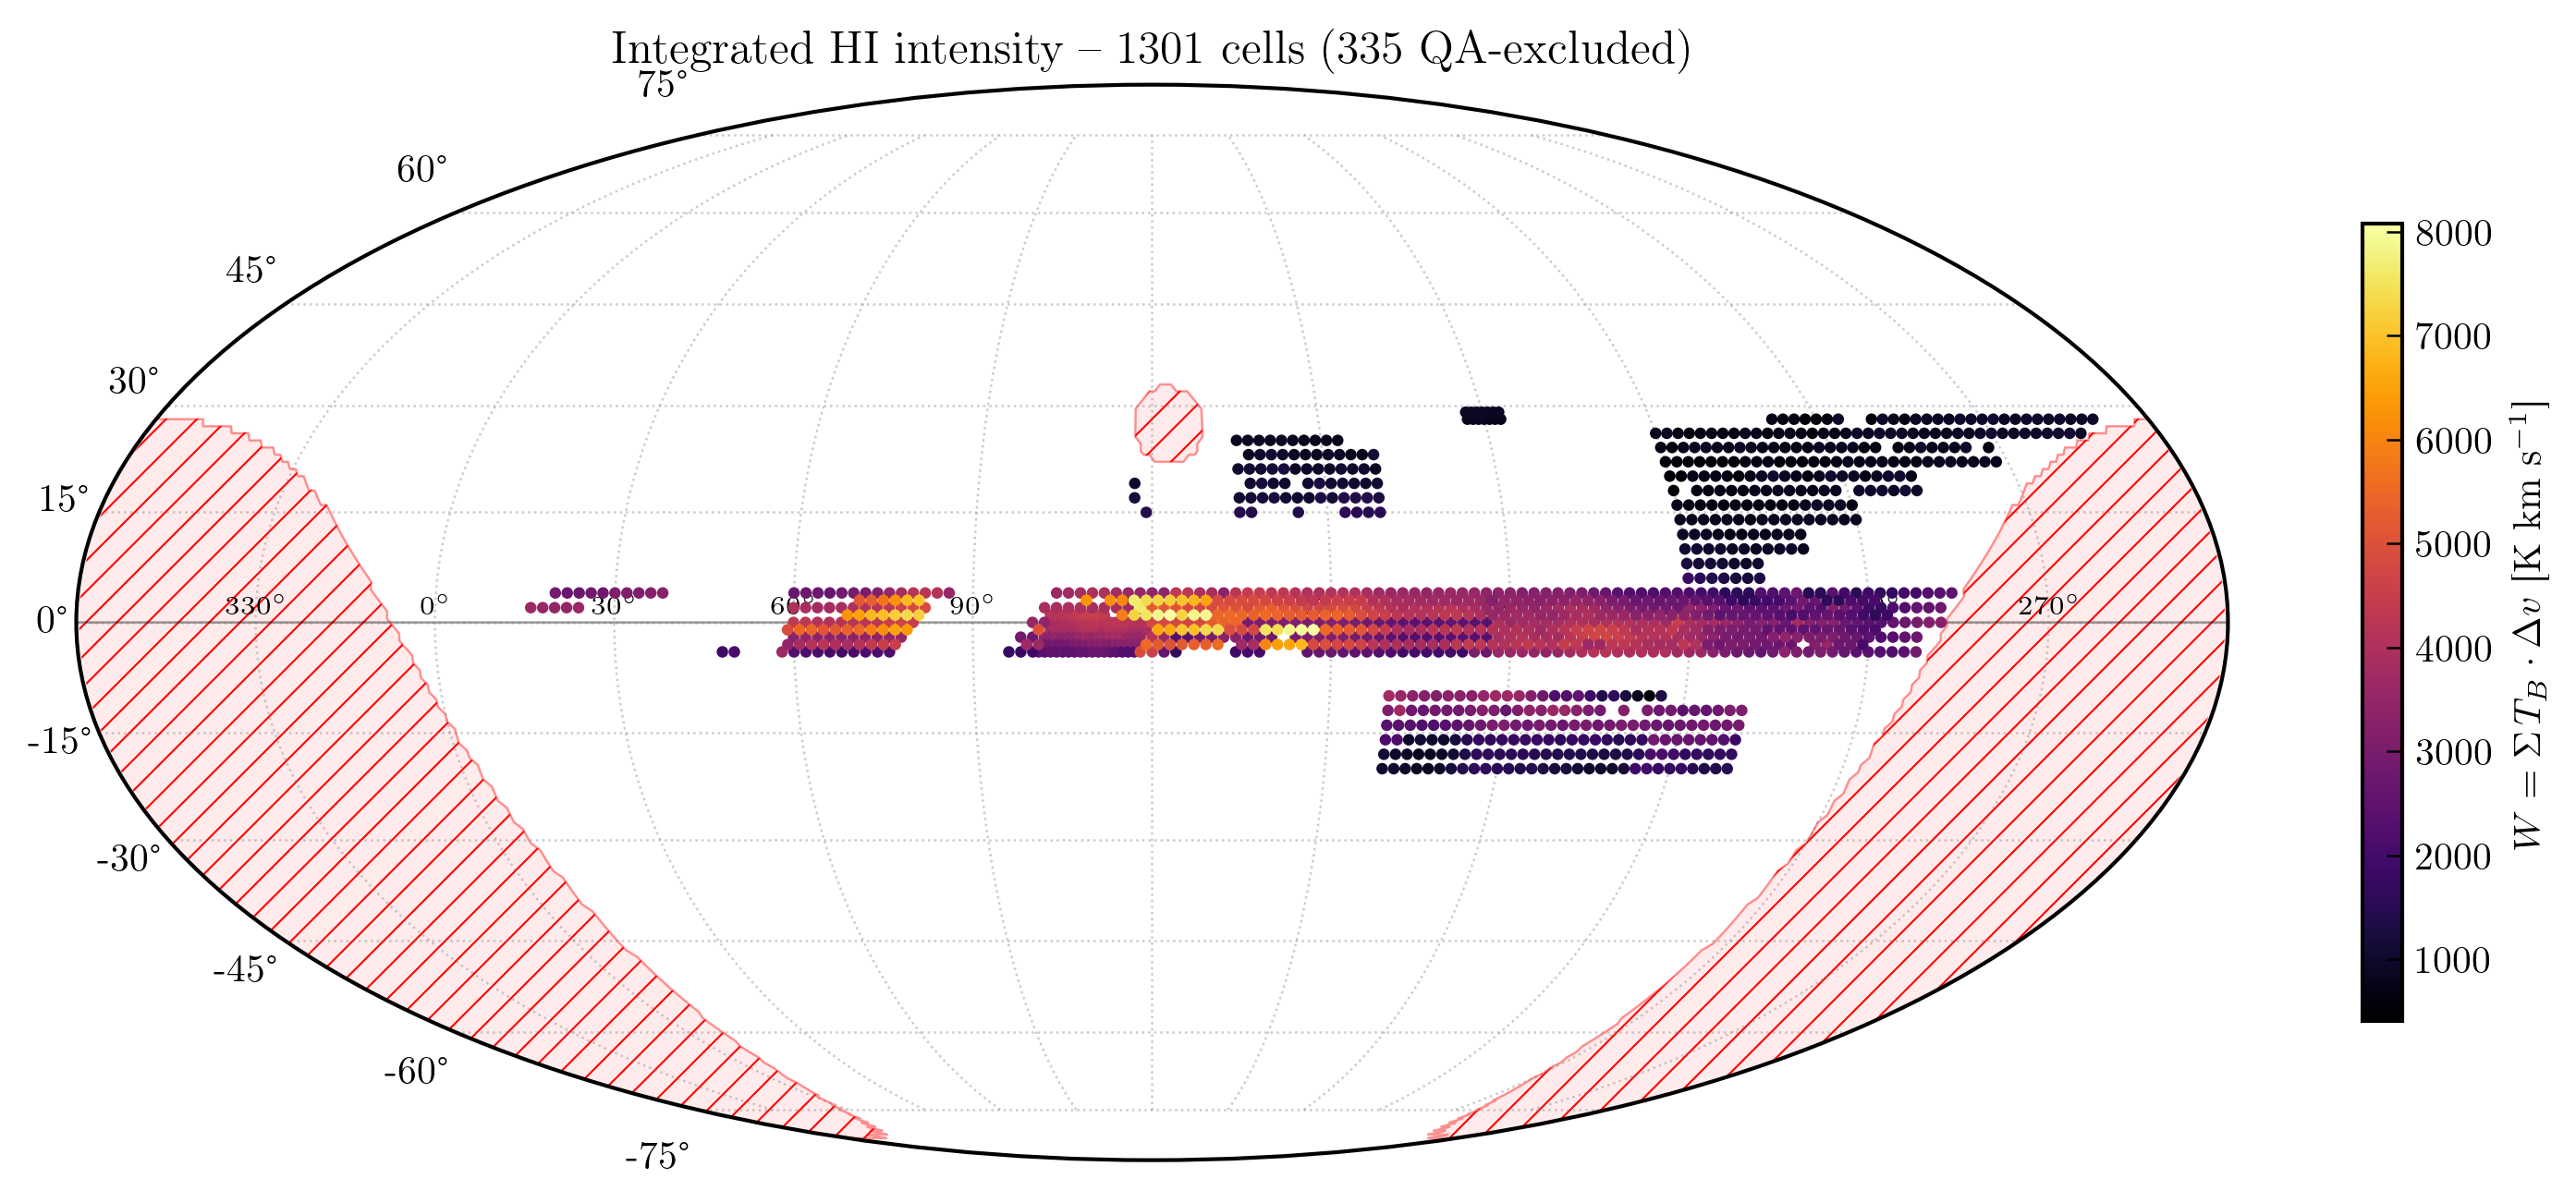

In [13]:
# QA-flagged cells to exclude (neighbor + T_sys outliers)
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
qa_flagged_set |= {(c['gl'], c['gb']) for c in tsys_flagged}

cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]

if not cell_keys_clean:
    print('No clean cells -- skipping W map')
else:
    gl_arr = np.array([k[0] for k in cell_keys_clean])
    gb_arr = np.array([k[1] for k in cell_keys_clean])
    TB_stack = np.stack([cell_combined[k]['T_B'] for k in cell_keys_clean])

    W = np.nansum(TB_stack, axis=1) * dv_kms
    valid = np.isfinite(W)

    fig, ax = plot_survey_mollweide(
        gl_arr[valid], gb_arr[valid], W[valid],
        center_l=MOLL_CENTER_L,
        cbar_label=r'$W = \Sigma\, T_B \cdot \Delta v$ [K km s$^{-1}$]',
        cmap='inferno',
        marker_size=SS_FINE,
        title=f'Integrated HI intensity -- {valid.sum()} cells ({len(qa_flagged_set)} QA-excluded)',
    )
    plt.show()

In [14]:
# Export state for downstream notebooks (l-v diagrams, diagnostics, etc.).
import pickle

STATE_PATH = Path('scan_load_state.pkl')

tsys_by_session = {
    s: float(v['T_sys']) for s, v in session_calib.items()
    if np.isfinite(v.get('T_sys', np.nan))
}
gain_med_by_session = {
    s: float(np.nanmedian(v['gain'])) for s, v in session_calib.items()
}

state = {
    'cell_combined': cell_combined,
    'qa_flagged_set': qa_flagged_set,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'tsys_by_session': tsys_by_session,
    'gain_med_by_session': gain_med_by_session,
    'sessions': sessions,
    'T_CAL_I': T_CAL_I,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} cells, {len(qa_flagged_set)} QA-flagged, '
      f'{len(tsys_by_session)} sessions calibrated')

Wrote scan_load_state.pkl (11.11 MB) -- 1636 cells, 335 QA-flagged, 36 sessions calibrated
